# Exploratory data analysis

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from pyprojroot.here import here

## Import data

In [17]:
df_returns = pd.read_csv('raw_data/returns.csv')
# Convert columns to lowercase
df_returns.columns = [col.lower() for col in df_returns.columns]

df_kcal = pd.read_csv('raw_data/kcal.csv')
df_kcal.columns = [col.lower() for col in df_kcal.columns]

df_recall = pd.read_csv('raw_data/recall.csv')
df_recall.columns = [col.lower() for col in df_recall.columns]

df_group = pd.read_csv('raw_data/groups.csv')
df_group.columns = [col.lower() for col in df_group.columns]

df_camp_members = pd.read_csv('raw_data/camp_members.csv')
df_camp_members.columns = [col.lower() for col in df_camp_members.columns]


In [18]:
# make dates have some format
df_group['date'] = pd.to_datetime(df_group['date'], dayfirst=True)
df_returns['date'] = pd.to_datetime(df_returns['date'], dayfirst=True)

/var/folders/7g/c1kcr6_s3rz5b1cdfg6ljfc40000gn/T/ipykernel_81961/3330818804.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_returns['date'] = pd.to_datetime(df_returns['date'], dayfirst=True)


In [19]:
df_group['group'] = df_group['group'].astype(str)
df_group['id'] = df_group['id'].astype(str)

solo_foraging = df_group['group'] == '0'
id_if_true = df_group['date'].astype(str) + '_' + df_group['id']
id_if_false = df_group['date'].astype(str) + '_' + df_group['group'] # Assuming group is integer/float, convert to str

df_group['group_id'] = np.where(solo_foraging, id_if_true, id_if_false)

df_group.tail()

,date,id,group,date_depart,depart,date_arrive,arrive,activity,activity.type,time.out,total.minutes,precision,group_id
2678,2018-08-06,2522,25,06/08/2018,19.49,06/08/2018,23.11,Fish,Foraging,3.22,202,Observed,2018-08-06_25
2679,2018-08-06,2544,25,06/08/2018,20.01,06/08/2018,21.38,Fish,Foraging,1.37,97,Observed,2018-08-06_25
2680,2018-08-06,3077,25,06/08/2018,20.01,06/08/2018,21.38,Fish,Foraging,1.37,97,Observed,2018-08-06_25
2681,2018-08-06,3117,25,06/08/2018,19.39,06/08/2018,23.11,Fish,Foraging,3.32,212,Observed,2018-08-06_25
2682,2018-08-06,3118,25,06/08/2018,20.01,06/08/2018,21.38,Fish,Foraging,1.37,97,Observed,2018-08-06_25


In [22]:
df_group_foraging = df_group[df_group['activity.type'] == "Foraging"]

# make a new group dataframe with the group_id as the index, concatenate only the unique ids within each 
df_group_agg = df_group_foraging.groupby('group_id').agg({'id': lambda x: '_'.join(sorted([str(item) for item in x.unique()])), 'total.minutes': 'mean', 'date_arrive': 'first'}).reset_index()
# get the number of unique ids within each group, split the ids into a list and count the number of unique ids
df_group_agg['id_count'] = df_group_agg['id'].apply(lambda x: len(x.split('_')))
df_group_agg

,group_id,id,total.minutes,date_arrive,id_count
0,2018-07-23_1,1007_1008_1009_1010_1016_1031_3077,29.714286,23/07/2018,7
1,2018-07-23_10,1007_1008_1009_1010_1011_1016,35.166667,23/07/2018,6
2,2018-07-23_1101,1101,14.000000,23/07/2018,1
3,2018-07-23_1102,1102,35.000000,23/07/2018,1
4,2018-07-23_1119,1119,67.000000,23/07/2018,1
...,...,...,...,...,...
755,2018-09-02_2038,2038,367.000000,02/09/2018,1
756,2018-09-02_4,1023_1028_1106_1116_2031_2039_2522_2544_3061_3117,501.700000,02/09/2018,10
757,2018-09-02_5,1009_1031_2538_2542_3142,188.600000,02/09/2018,5
758,2018-09-02_6,1008_1010_1016_2513_2539,62.000000,02/09/2018,5


In [23]:
# Get the date for each group_id
df_group_agg['date'] = df_group_agg['group_id'].str.split('_').str[0]
df_group_agg.head()

,group_id,id,total.minutes,date_arrive,id_count,date
0,2018-07-23_1,1007_1008_1009_1010_1016_1031_3077,29.714286,23/07/2018,7,2018-07-23
1,2018-07-23_10,1007_1008_1009_1010_1011_1016,35.166667,23/07/2018,6,2018-07-23
2,2018-07-23_1101,1101,14.000000,23/07/2018,1,2018-07-23
3,2018-07-23_1102,1102,35.000000,23/07/2018,1,2018-07-23
4,2018-07-23_1119,1119,67.000000,23/07/2018,1,2018-07-23


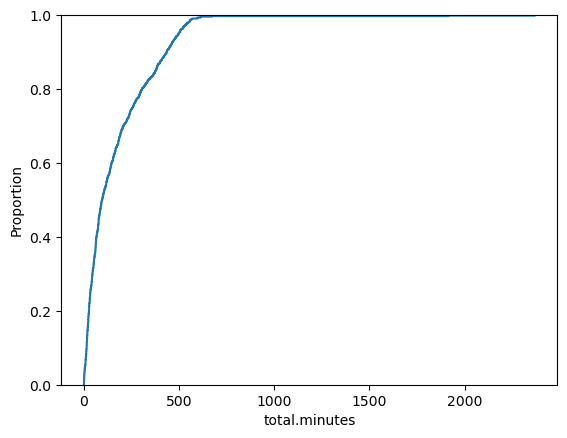

In [12]:
# one complicatio with matching to returns is the possibility of overnight or multi-day trips--but this is relatively rare
df_group["total.minutes"].describe()

# ECDFs of total.minutes
sns.ecdfplot(df_group_agg['total.minutes'])
plt.show()

In [15]:
# get fuzzy matches of returns to group_ids
# critera: must be of the same date, and the set of foragers should be maximally overlapping

df_returns

,date,pooled_group,index,net_food_weight_gram,gift,id,article,state
0,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible
1,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible
2,2018-08-01,1.0,55,1100.0,0.0,1010,ediki,with inedible
3,2018-08-01,10.0,14,100.0,0.0,2513,ekule,ready-to-eat
4,2018-08-01,10.0,14,100.0,0.0,2039,ekule,ready-to-eat
...,...,...,...,...,...,...,...,...
2509,2018-09-02,NaN,35,7100.0,0.0,1115,mela,ready-to-eat
2510,2018-09-02,NaN,35,8000.0,0.0,1116,mela,ready-to-eat
2511,2018-09-02,NaN,6,9375.0,0.0,2038,palm nut,with thorns
2512,2018-09-02,NaN,35,9500.0,0.0,1120,mela,ready-to-eat


In [7]:
df_returns['net_food_weight_gram'].describe()

count     2514.000000
mean      2011.250322
std       3146.854832
min          0.900000
25%        300.000000
50%        900.000000
75%       2200.000000
max      27000.000000
Name: net_food_weight_gram, dtype: float64

In [14]:
df_kcal.head()

,index,yaka,english,processing_condition,kcal.g
0,1,Mobe,Unknown,whole,0.597857143
1,2,Maondo,Unknown,whole,0.224772727
2,3,Maika,Taro,Tuber without periderm,1.27
3,4,Dunda,Taro leaves,Leaves with petiole,0.234
4,5,Mbila,Palm nut,many fruits with bracts,2.97


In [295]:
df_returns.head()
df_returns['pooled_group'].unique()

array([ 1., 10., 11.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 12., 13.,
       14., 15., 16., 17., 18., nan])

In [296]:
df_recall.head()

,date,gift,id,pooled_group,article_consumed,quantity,x1_unit_weight_grams,index,source,total_weight_grams
0,23/07/2018,0,1032,0,maondo-with peel,5.0,429,2.0,fieldnotes.,2145.0
1,23/07/2018,0,1102,0,palm nuts,10.0,9,8.0,"Davies, R. M. (2012). Physical and mechanical ...",90.0
2,24/07/2018,0,3041,0,orange,1.0,131,45.0,USDA with peel.,131.0
3,25/07/2018,0,3077,0,palm nuts,10.0,9,8.0,"Davies, R. M. (2012). Physical and mechanical ...",90.0
4,26/07/2018,0,2513,0,honey,0.5,1420,91.0,"According to U.S. Department of Agriculture, ...",710.0


In [297]:
# Merge to get kcal as rate
df_merged = pd.merge(df_returns, df_kcal[['index', 'kcal.g']], on='index', how='left')

In [298]:
df_merged.head()

,date,pooled_group,index,net_food_weight_gram,gift,id,article,state,kcal.g
0,2018-08-01,1.0,55,1100.0,0.0,1030,ediki,with inedible,0.1225
1,2018-08-01,1.0,55,1100.0,0.0,2523,ediki,with inedible,0.1225
2,2018-08-01,1.0,55,1100.0,0.0,1010,ediki,with inedible,0.1225
3,2018-08-01,10.0,14,100.0,0.0,2513,ekule,ready-to-eat,1.19
4,2018-08-01,10.0,14,100.0,0.0,2039,ekule,ready-to-eat,1.19


In [299]:
df_merged['kcal.g'] = pd.to_numeric(df_merged['kcal.g'], errors='coerce')
df_merged['kcal.g'].dtypes

dtype('float64')

<Axes: >

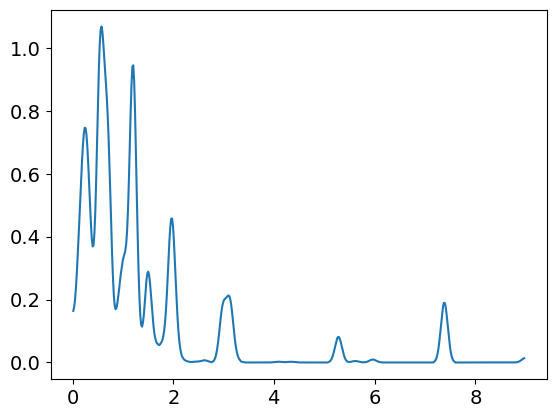

In [300]:
import arviz as az
az.plot_dist(df_merged['kcal.g'])

<Axes: >

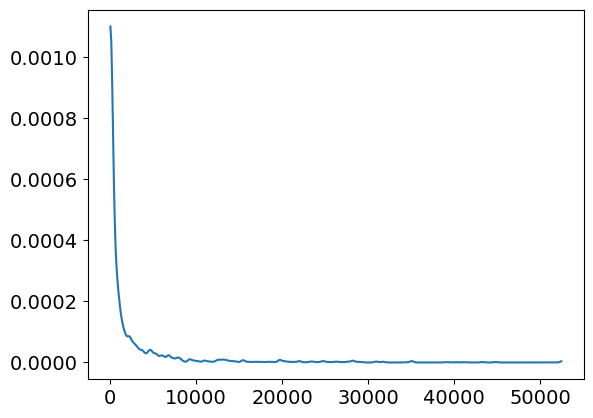

In [301]:
df_merged['kcal'] = df_merged['kcal.g'] * df_merged['net_food_weight_gram']

az.plot_dist(df_merged['kcal'])


In [302]:
df_merged['net_food_weight_gram'].describe()

count     2514.000000
mean      2011.250322
std       3146.854832
min          0.900000
25%        300.000000
50%        900.000000
75%       2200.000000
max      27000.000000
Name: net_food_weight_gram, dtype: float64

In [303]:
df_merged = df_merged[df_merged["gift"] == 0].drop(columns=["gift"])
df_merged.head()

,date,pooled_group,index,net_food_weight_gram,id,article,state,kcal.g,kcal
0,2018-08-01,1.0,55,1100.0,1030,ediki,with inedible,0.1225,134.75
1,2018-08-01,1.0,55,1100.0,2523,ediki,with inedible,0.1225,134.75
2,2018-08-01,1.0,55,1100.0,1010,ediki,with inedible,0.1225,134.75
3,2018-08-01,10.0,14,100.0,2513,ekule,ready-to-eat,1.1900,119.00
4,2018-08-01,10.0,14,100.0,2039,ekule,ready-to-eat,1.1900,119.00


In [304]:
df_merged['pooled_group'] = np.round(df_merged['pooled_group'].fillna(0), 0).astype(int).astype(str)
df_merged['id'] = df_merged['id'].astype(str)

df_merged['pooled_group'].unique()

array(['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9', '12',
       '13', '14', '15', '16', '17', '18', '0'], dtype=object)

In [305]:
solo_foraging = df_merged['pooled_group'] == '0'
id_if_true = df_merged['date'].astype(str) + '_' + df_merged['id']
id_if_false = df_merged['date'].astype(str) + '_' + df_merged['pooled_group'] # Assuming group is integer/float, convert to str

df_merged['group_id'] = np.where(solo_foraging, id_if_true, id_if_false)

In [306]:
df_merged.head()

,date,pooled_group,index,net_food_weight_gram,id,article,state,kcal.g,kcal,group_id
0,2018-08-01,1,55,1100.0,1030,ediki,with inedible,0.1225,134.75,2018-08-01_1
1,2018-08-01,1,55,1100.0,2523,ediki,with inedible,0.1225,134.75,2018-08-01_1
2,2018-08-01,1,55,1100.0,1010,ediki,with inedible,0.1225,134.75,2018-08-01_1
3,2018-08-01,10,14,100.0,2513,ekule,ready-to-eat,1.1900,119.00,2018-08-01_10
4,2018-08-01,10,14,100.0,2039,ekule,ready-to-eat,1.1900,119.00,2018-08-01_10


In [307]:
df_merged_agg = df_merged.groupby('group_id').agg({'kcal': 'mean'}).reset_index()
df_merged_agg.head()


,group_id,kcal
0,2018-07-23_1,247.250000
1,2018-07-23_1006,197.198835
2,2018-07-23_1009,112.685048
3,2018-07-23_1032,84.364444
4,2018-07-23_1102,6742.603385


In [308]:
df_merged_agg.head()

,group_id,kcal
0,2018-07-23_1,247.250000
1,2018-07-23_1006,197.198835
2,2018-07-23_1009,112.685048
3,2018-07-23_1032,84.364444
4,2018-07-23_1102,6742.603385


In [309]:
df_group_agg

# look at group_ids that start with 2018-07-23
df_group_agg[df_group_agg['group_id'].str.startswith('2018-07-23')]["group_id"].unique()


array(['2018-07-23_1', '2018-07-23_10', '2018-07-23_1101',
       '2018-07-23_1102', '2018-07-23_1119', '2018-07-23_2',
       '2018-07-23_3', '2018-07-23_3040', '2018-07-23_6', '2018-07-23_7',
       '2018-07-23_8', '2018-07-23_9'], dtype=object)

In [310]:
len(df_merged_agg), len(df_group_agg) # hypothesis is that df_merged_agg has more group_ids than df_group_agg, because it includes the group_ids from the returns dataframe not filtered by activity.type == "Foraging"

(1107, 760)

In [311]:

# Join the two dataframes on the group_id column, fill missing values with 0
df_joined = pd.merge(df_group_agg[['group_id', 'total.minutes']], df_merged_agg, on='group_id', how='left')

In [312]:
np.sum(df_joined['kcal'] == 0), np.sum(df_joined["kcal"].isna())

(np.int64(1), np.int64(379))

In [313]:
df_joined["kcal"] = df_joined["kcal"].fillna(0)
np.mean(df_joined['kcal'] == 0)

np.float64(0.5)

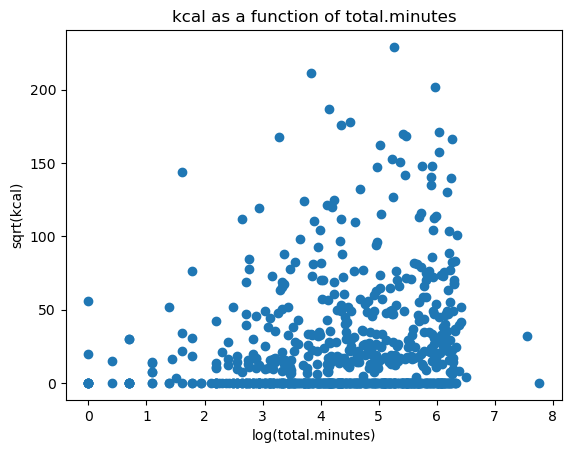

In [314]:
plt.scatter(np.log(df_joined['total.minutes']), np.sqrt(df_joined['kcal']))
plt.xlabel('log(total.minutes)')
plt.ylabel('sqrt(kcal)')
plt.title('kcal as a function of total.minutes')
plt.show()


In [331]:
# Get forager demographic info
df_camp_members['age'] = df_camp_members['birthyear'].apply(lambda x: 2018 - x)
df_foragers = df_camp_members[['id', 'sex', 'age']]
df_foragers.head()

# recode sex as "male" and "female"
df_foragers['sex'] = df_foragers['sex'].apply(lambda x: "male" if x == "M" else "female")
df_foragers.head()

/var/folders/7g/c1kcr6_s3rz5b1cdfg6ljfc40000gn/T/ipykernel_38527/727636300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foragers['sex'] = df_foragers['sex'].apply(lambda x: "male" if x == "M" else "female")


,id,sex,age
0,1006,male,17
1,1007,male,13
2,1008,female,9
3,1009,female,4
4,1010,male,10


In [334]:
unique_forager_ids = df_group_agg['id'].apply(lambda x: x.split('_')).explode().unique()

In [336]:
df_foragers = df_foragers[df_foragers['id'].isin(unique_forager_ids)]

In [337]:
# Export
df_foragers.to_csv('data/foragers.csv', index=False)
df_group_agg.to_csv('data/groups.csv', index=False)
df_joined.to_csv('data/returns.csv', index=False)

In [24]:
df_group_agg.to_csv('data/groups.csv', index=False)